## INHERITING FROM THE OBJECT BASE CLASS

At this point in time you're familiar with how classes can be used to represent entities in the real world. You can have a class representing an animal, a student, a circle, or any other shape.

Now classes are actually much more powerful because you can use subclasses and inheritance in order to model relationships. Subclasses in Python are child classes that inherit from a parent class and there exists 'IS-A' relationship between a child class and a parent class. In order to understand how subclasses look, let's start off by defining a few classes. Here is a Shape class with no body defined.

In [1]:
class Shape:
    pass

Another way you can define a class is by saying, class, that is the keyword, Shape, followed by an empty pair of parentheses.


In [2]:
class Shape():
    pass

#### This is a completely valid definition. It's not often used unless you're planning to have this class inherit from something. We'll get to that in a little bit. The common way is used to use the first definition by omitting the parenthesis altogether. I'm going to define a shape class in one more way, which is again, valid.

In [1]:
class Shape(object):
    pass

#### Class Shape, and within parenthesis I've specified object. Notice that object is a keyword in Python. You can tell because the Jupyter notebook has colored the object keyword green. What this really means is that the shape class inherits from the class object which is a built-in class available by default. Now, this is typically implied when you don't specify the class that you inherit from.

#### So all three definitions of the Shape class here are valid and in all three cases the Shape class inherits from the built-in object class. In the first two shape definitions, this inheritance is implied, in the third we make it explicit. Now that you understood the three valid ways in which we can set up a Shape class, let's go ahead and define some actual code body for this class. Here is the class Shape, we haven't specified any parenthesis.

In [2]:
class Shape:
    
    def __init__(self, shape_type):
        self.__type= shape_type
        
    def get_type(self):
        return self.__type

In [3]:
circle = Shape('circle')

type(circle)

__main__.Shape

In [4]:
circle.get_type()

'circle'

In [5]:
square = Shape('square')

type(square)

__main__.Shape

In [6]:
square.get_type()

'square'

You can call square.get_type() and it will tell you that it's a square, but it's of type shape. Now this is totally fine. There is nothing wrong with this class setup.

So long as the attributes that you want associated with objects of this class are common to all shapes. Let me explain what I'm talking about here. Here is an updated definition for the shape class.

In [7]:
class Shape:
    
    def __init__(self, shape_type, color ='Red'):
        self.__type= shape_type
        self.__color = color
        
    def get_type(self):
        return self.__type
    
    def get_color(self):
        return self.__color

The init method takes in two input arguments, one of which is required and the other is optional. It has a default value. The shape type is the required argument. You have to specify a value for this. Color is optional because it has the default value red. In the init method, we assign shape_type to the type instance variable and color to the color instance variable.

Now this is totally fine because no matter what type of shape it is, whether it's a square, circle, rectangle, or triangle, all shapes can have a color. We have the get_type which returns the type of the shape and the get_color which returns the color of the shape instance that you're working with. Let's instantiate a shape with the shape_type circle.

In [8]:
circle = Shape('circle')

circle.get_color()

'Red'

Observe that we haven't specified a value for the color when we instantiate the shape, that means this shape will have the default color red. Using the circle variable, if you call circle.get_color(), you'll see that this circle is red in color.

If you don't want your shapes to be the default red color, simply specify the color when you instantiate the shape object.

In [9]:
square = Shape('square', color = 'Blue')

square.get_color()

'Blue'

## MODELING IS-A RELATIONSHIP USING SUBCLASSES

But let's say you want instance of a shape object to be able to calculate the area and the perimeter of that shape. Let's set up a Shape class to do exactly that.

In [10]:
class Shape:
    
    def __init__(self, shape_type, color ='Red'):
        self.__type= shape_type
        self.__color = color
        
    def get_type(self):
        return self.__type
    
    def get_color(self):
        return self.__color
    
    def get_area(self):
        pass
    
    def get_perimeter(self):
        pass

This Shape class, if we take a look at this init method, takes in the type of shape and the color exactly like before. We have the get_type and the get_color functions. And then we have the two functions here, get_area and get_perimeter and immediately we're up against a little roadblock. Now if you remember your middle-school math, the formula for a square and a circle for calculating the area and the perimeter are completely different. In order to calculate the area and perimeter for a circle, we need to know the radius of a circle.

For a square, we need to know the length of an edge of a square. Now, this is simple if you only consider the shapes circle and square, but what if you add in a triangle? What if we add in a rectangle, and here is where the complexity gets very hard to manage. Now, it's pretty obvious that the code that you write within the get_area and get_perimeter functions, will be different based on the shape type, whether it's a circle, triangle, trapezoid, anything.

And this is where you see the limitations of having a single shape class represent all shape types represent a circle, and all other types using the single shape class is actually quite hard. And this is why we've kind of thrown up our hands here and not really written any code for the get_area and get_perimeter functions. Let's now instantiate an object of type shape. I want the shape to be a circle.

In [11]:
s = Shape('circle')

s.get_color()

'Red'

In [12]:
s.get_area()

In [13]:
s.get_perimeter()

It'll have the default color red when I call get_area, it returns nothing because we had pass in the get_area function and get_perimeter also returns nothing.

Well, what we really need here is a way to say that circle is basically a shape and it has some attributes such as color, which are common across all shapes.

And the circle shape might have some special attributes that are uniquely associated with circles, such as the radius of the circle. Also the way we calculate the area and perimeter for a circle will be different from other shapes. How can we set this up? We'll have the circle class inherit from the Shape class that you had set up earlier. 

#### The way you specified inheritance between classes, is using the syntax that you see here on screen

In [16]:
class Circle(Shape):
    pass

We've defined the new class here called circle, and within parenthesis we've specified shape. Shape is the class that he had defined earlier and here the circle class inherits from shape. Before we proceed further, let's get some terminology out of the way, so that when I use those terms later on, you know what they mean. 

#### Here shape is the base class. 

#### The class from which you derive other classes is referred to as the base class.

#### Other ways to refer to the shape class here is the parent class or the superclass. On the other hand, the circle class is referred to as the derived class. It is derived from the shape class. It's also referred to as the child class or the subclass of shape. We haven't specified any code body for the circle class yet, this is why we have pass.

Now that we've defined the circle class, let's create an instance of the circle class and we do so in the same way like we would with the Shape class, circle = Circle(). Will this work? Let's see, immediately you see that this is an error and the error is actually quite meaningful.

In [17]:
circle = Circle()

TypeError: __init__() missing 1 required positional argument: 'shape_type'

The init method requires one positional argument shape type and that's not been provided. Now you might see that the shape type is required for the Shape class, but we were trying to instantiate a circle. Well, a circle is a shape. If you remember our Shape class definition from earlier it took in a required input argument, shape_type. When we try to instantiate the circle, we haven't specified any value for shape_type, so we can't instantiate the circle in this way.

So what really happened was when you try to instantiate a circle under the hood, the circle class invoked the init method defined in Shape because circle is a shape. Now this init method requires a shape type. We didn't provide that and that's why we saw this error. So how can we instantiate a circle? Here is an instantiation that will work. We instantiate a circle, and pass in a value for the required shape type argument..

In [18]:
circle = Circle('circle')

type(circle)

__main__.Circle

The value here is shape type of circle and we assign this to the circle variable. And let's take a look at the type of the circle variable. Type of circle will tell you that this circle variable is actually an instance of the circle class.

With this information you can't really tell that the circle is a shape, but the circle variable is definitely an object of type circle. The ability to model is-a relationships using inheritance is very powerful. For example, you could have a Square class, which also inherits from the Shape class. Square here is the derived class, Shape is the base class.

In [19]:
class Square(Shape):
    pass


In [20]:
square = Square('square')

type(square)

__main__.Square

The syntax for specifying inheritance is one that you've seen before. We define the Square class and within parenthesis specifies that it inherits from Shape. Instantiating an object of type square is similar to how we instantiate the circle. Remember, square is a shape, that means you need to pass in a value for the shape type perimeter.

So we pass in square and if you take a look at the type of square you'll see that it is of our custom square type.

## INVOKING BASE CLASS METHODS FROM SUBCLASSES

If you've been following along closely, you must admit it's kind of weird to have a special class for circle and special class for square, but you still have to specify the shape type. Now it's weird and it's really not a nice way to have these classes set up. Can we somehow not have to specify the shape type? Well yes, and that's exactly what we'll see next. Here, I'm going to redefine the circle class.

In [29]:
class Circle(Shape):
    
    def __init__(self):
        Shape.__init__(self, 'Circle')

Once again a circle will inherit some shape as you can see in the class definition, but this circle class has its own init method. The init method of the circle class takes in no additional input arguments beyond self, that is a reference to the current instance. But within the body of the init method, we invoke the init method of the parent shape class. This means that the right classes can explicitly call methods that belong to the base class.

There are several ways to do this. Here is one syntax which is correct. So the base classes shape to be called shape.init pass in the current instance self and pass in the shape_type. Remember the init method of the shape base class requires the shape_type as a parameter. Observe how we have passed in the shape_type parameter inside the circle class.

So when users of the circle class instantiate a circle, they don't have to worry about the shape_type. So if you were to define another class which represents another shape, such as a square, square inherits from the shape base class once again.

In [21]:
class Square(Shape):
    
    def __init__(self):
        Shape.__init__(self, 'Square')
        
## Within its init method, it calls the init method of the shape base class, but the shape type that it 
## passes in is square.

Within its init method, it calls the init method of the shape base class, but the shape type that it passes in is square.

Now let's instantiate an object of type circle and an object of type square, and you'll find that these instantiations are much more intuitive, you don't have to pass in a shape type when you create these objects. If you pass in the circle and square objects to the type built-in function, you'll be able to see that they belong to custom type circle and square. So you can see that the types of these two objects are different. They're derived from the same base class.

In [34]:
circle = Circle() 

square = Square()

type(circle), type(square)

(__main__.Circle, __main__.Square)

In [35]:
circle.get_type()

'Circle'

In [36]:
square.get_type()

'Square'

If you call circle.get_color() and square.get_color(), you'll find that they'll have the default color which is red. One of the input arguments to the init method of the shape class is the color.

In [39]:
circle.get_color()

'Red'

In [40]:
square.get_color()

'Red'

We haven't specified the color when we set up the circle and the square classes. This means that any object of type circle or square will always have the color red, and this is borne out by the fact when you call circle.get_color() or square.color, the response is red.

Let's redefine our circle class so that you can explicitly specify a color for a circle as well. This means you have to add in the color as an input argument to the init method of the circle class.

In [41]:
class Circle(Shape):
    
    def __init__(self,color='Green'):
        Shape.__init__(self, 'Circle',color)

We've also specified a default value for the color of a circle. Circles are by default green in color, but you can specify some different color as well thanks to this input argument. This time, when the circle class invokes the init method of the shape base class, it passes in color as an input argument to this invocation. Now, with this definition of circle, it's possible for you to instantiate circle objects of different colors.

In [45]:
circle = Circle()

##If you simply specify circle and do not pass in a value for the color, it will get the default color and that is green.

In [46]:
circle.get_color()

'Green'

In [47]:
##But if you want to instantiate a shape object of a different color, that's possible as well.
## Simply pass in the color as an input argument when you create a circle object. If you call circle.get_color(), 
## you'll see that the circle is Orange

circle = Circle('Orange')

circle.get_color()

'Orange'

In [54]:
class Square(Shape):
    
    def __init__(self,color):
        Shape.__init__(self, 'Square',color)

In [55]:
square = Square()

##But observe here that we haven't specified a default value for the color input argument for square. The init method for 
##square invokes the init method in the base shape class and 
##passes in this color argument to the base init method as well.


TypeError: __init__() missing 1 required positional argument: 'color'

Because we don't have a default value for the color of a square, when you instantiate a square object like this without specifying the color, you'll find that this is an error. Python says:

There is a required positional argument color and we haven't specified any value for color. So when you instantiate a square, you have to specify a value for color because it doesn't have a default value.

In [56]:
square = Square('Blue')

In [57]:
square.get_color()

'Blue'

In [58]:
square = Square('Yellow')

square.get_color()

'Yellow'

## DEFINING IMPLEMENTATIONS OF BASE CLASS METHODS

In [59]:
import math

class Circle(Shape):
    
    def __init__(self, radius):
        Shape.__init__(self, 'circle')
        
        self.__radius = radius
        
    def get_area(self):
        return math.pi * self.__radius * self.__radius
    
    def get_perimeter(self):
        return 2 * math.pi * self.__radius

In [60]:
c = Circle(10)

In [61]:
c.get_area()

314.1592653589793

In [62]:
c.get_perimeter()

62.83185307179586

In [63]:
class Square(Shape):
    
    def __init__(self, side):
        Shape.__init__(self, 'square')
        
        self.__side = side
        
    def get_area(self):
        return self.__side * self.__side
    
    def get_perimeter(self):
        return 4 * self.__side

In [65]:
s = Square()

TypeError: __init__() missing 1 required positional argument: 'side'

In [66]:
s = Square(10)

In [67]:
s.get_area()

100

In [68]:
s.get_perimeter()

40

Observe how inheritance allows us to specify that both squares and circles are of type Shape. They have color and they have a shape type, but they have other attributes that are different.A circle has a radius, a square has the length of a side, but they are still shapes.

In this instance, once again, the Shape base class has served to tell us that shapes have an area and perimeter. I don't know how to calculate it as a base class, but the derived classes do. And the Square derived class has specified how the area and the perimeter should be calculated for a square.

## SUPERCLASS AND SUBCLASS HIERARCHIES

We'll use this demo to reinforce whatever concepts we've studied so far about classes as well as inheritance. We'll also learn a few additional concepts along the way. Here is the class Competition that we worked with earlier.

This is the class that we used to represent some kind of sporting competition or any other kind of competition, essays, debating, and so on. We have the __raise_amount variable, which is a class variable. This has the same value for all instances of the Competition class. The value of the __raise_amount class variable is 1.1. This is the proportion by which we will increment the prize money if we want to.

The init method here takes in the name of the competition and the prize money. We have get us for the name of the competition as well as for the prize money and we have a function called raise_prize. Which basically increases the prize money by the raise amount. 

In [44]:
class Competition:
    
    __raise_amount =1.10
    
    def __init__(self, name, prize):
        self.__name = name
        self.__prize = prize
        
    def get_name(self):
        return self.__name
    
    def get_prize(self):
        return self.__prize
    
    def raise_prize(self):
        self.__prize = self.__prize * self.__raise_amount

Let's now instantiate an object of class Competition. This is a race, it can be any kind of race, running race, anything.

In [45]:
race = Competition('Race', 100) 

type(race)

__main__.Competition

The name of the competition is race and the prize money is a $100. If you try to find the type of this race variable, you can see that it's of type Competition. This is the custom type that we've defined. I'm now going to introduce this very useful built-in function available in Python, that is the help function.

In [46]:
help(Competition)

Help on class Competition in module __main__:

class Competition(builtins.object)
 |  Competition(name, prize)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, name, prize)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  get_name(self)
 |  
 |  get_prize(self)
 |  
 |  raise_prize(self)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



Take a look at the line at the very top that says, class Competition. You can see that it inherits from the built-in object class. Even though we haven't explicitly specified, that competition derives from object, you can see using this help documentation that it does. You can see the methods that we've defined on Competition, the init method, get_name, get_prize, and the raise_prize. And in addition, you can see the input arguments for all of these methods.

We haven't encountered the help method before, but we've already seen how we can access the dictionary that corresponds to a particular class in order to see what keys and values are present in this dictionary. The dictionary corresponding to a class contain all of the class variables, which in the case of Competition, is the raise_amount variable.



In [47]:
Competition.__dict__

mappingproxy({'__module__': '__main__',
              '_Competition__raise_amount': 1.1,
              '__init__': <function __main__.Competition.__init__(self, name, prize)>,
              'get_name': <function __main__.Competition.get_name(self)>,
              'get_prize': <function __main__.Competition.get_prize(self)>,
              'raise_prize': <function __main__.Competition.raise_prize(self)>,
              '__dict__': <attribute '__dict__' of 'Competition' objects>,
              '__weakref__': <attribute '__weakref__' of 'Competition' objects>,
              '__doc__': None})

In addition, all of the methods are also associated with the class itself. We have the init method, the get_name, get_prize, and raise_prize. Now let's create a sub class which derives from this base Competition class. We'll use these sub classes to represent specific kinds of competition

In [48]:
class Sprint(Competition): 
    pass

Here, we have a very simple definition for the class Sprint which inherits from Competition. We haven't defined any code body yet for this class, which is why we have pass. Now, if you pass in this Sprint class as an input argument to the help function, you'll find something interesting.

In [49]:
help(Sprint)

Help on class Sprint in module __main__:

class Sprint(Competition)
 |  Sprint(name, prize)
 |  
 |  Method resolution order:
 |      Sprint
 |      Competition
 |      builtins.object
 |  
 |  Methods inherited from Competition:
 |  
 |  __init__(self, name, prize)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  get_name(self)
 |  
 |  get_prize(self)
 |  
 |  raise_prize(self)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Competition:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



Observe that you can now see the class hierarchy associated with this Sprint class. Up top, you can see that the class Sprint inherits from Competition and you also have a method resolution order. If you invoke a method on an instance of class Sprint, your Python interpreter will first look for the code for that particular method in the Sprint class. If the code is not found there, it'll then look in the Competition class, and if it isn't found there as well, it will look in the builtins.object class.

This is the class inheritance hierarchy. Competition inherits from the object class and Sprint inherits from Competition. You can see that this help function very clearly tells you what methods the Sprint class has inherited from the Competition class, the initialization, the get_name, get_prize, and raise_prize. We've defined no code in the Sprint class so far. Let's take a look at the dictionary corresponding to the Competition base class.

In [50]:
Competition.__dict__

mappingproxy({'__module__': '__main__',
              '_Competition__raise_amount': 1.1,
              '__init__': <function __main__.Competition.__init__(self, name, prize)>,
              'get_name': <function __main__.Competition.get_name(self)>,
              'get_prize': <function __main__.Competition.get_prize(self)>,
              'raise_prize': <function __main__.Competition.raise_prize(self)>,
              '__dict__': <attribute '__dict__' of 'Competition' objects>,
              '__weakref__': <attribute '__weakref__' of 'Competition' objects>,
              '__doc__': None})

Here is what it is, we have the raise_amount class variable and the four functions or methods that have been defined in this class. If you take a look at the dictionary corresponding to the Sprint class, you'll find that it's pretty sparse.

In [31]:
Sprint.__dict__

mappingproxy({'__module__': '__main__', '__doc__': None})

Because Sprint doesn't have any code defined in its body, it inherits all of the methods and class variables from the Competition base class. Let's now instantiate an object of class Sprint. This is the 100 meter sprint, and the prize money is $700.

In [34]:
sprint = Sprint('100m', 700) 

type(sprint)

## If you print out the type of sprint, you can see that it is of custom type Sprint, which inherits from Competition.

__main__.Sprint

And if we take a look at the dictionary of this sprint object, you can see the name and the prize money associated with this instance.

In [35]:
sprint.__dict__

{'_Competition__name': '100m', '_Competition__prize': 700}

Remember that any variables declared inside a class which start with an underscore are renamed by Python so that they are not inadvertently changed. Now, the Sprint class itself may not have any code body defined for the class. Remember that we have specified pass inside the code body.

In [36]:
sprint.get_name(), sprint.get_prize()

('100m', 700)

However, it does inherit the get_name and get_prize methods from the Competition base class. So when you invoke these methods, these will automatically call the methods defined in competition. 

If you want to raise the prize money associated with the Sprint competition, you can call sprint.raise_prize().

In [37]:
sprint.raise_prize()

sprint.get_prize()

770.0000000000001

And when you look at the prize money now, you can see that it has been incremented by about 10%. So it goes from $700 to $770. I'll now instantiate a new object of type Competition. This time I want it to represent a chess competition.



In [38]:
chess = Competition('Chess', 1000)

We don't have a separate class for chess. So I'm going to instantiate the Competition class itself.

In [40]:
chess.get_prize()

1000

#### The prize money for the chess competition as we have specified when we instantiated the class is $1000. If you want to increase the prize money for the chess competition, you'll call chess.raise_prize(), and the prize money will be incremented by 10%, so now it's $1100.

In [42]:
chess.raise_prize(), chess.get_prize() 

(None, 1100.0)

At this point in time, this Sprint class with no body defined and the chess class, which is an instance of the class Competition are no different from one another.



## Defining Methods in the Subclass

In [71]:
class Cycling(Competition):
    
    def __init__(self, name, prize, country):
        super().__init__(name, prize)
        
        self.__country = country
        
    def get_country(self):
        return self.__country
        

In [72]:
cycling = Cycling('10km', 7500, 'USA')

type(cycling)

__main__.Cycling

In [73]:
cycling.get_country()

'USA'

In [74]:
cycling.get_name() , cycling.get_prize() 

('10km', 7500)

In [75]:
issubclass(Cycling, Competition)

True

In [76]:
class Shooting():
    
    def __init__(self, name):
        self.__name = name

In [77]:
issubclass(Shooting, Competition)

False

In [78]:
class Shooting(Competition):
    
    def __init__(self, name, prize):
        super().__init__(name, prize)

In [79]:
issubclass(Shooting, Competition)

True

In [80]:
class Shooting(Competition):
    
    def __init__(self, name, prize):
        Competition.__init__(name, prize) ## same as super()

Objectives
define methods in a subclass
[Video description begins] Topic title: Defining Methods in the Subclass. The presenter is Janani Ravi. [Video description ends]

But the whole idea of having subclasses is that they can have additional attributes. And be more interesting and more specific as compared with parent classes.

[Video description begins] The 09-MoreSubclassesAndInheritance module is open in the Jupyter notebook. It includes the following code, code starts: class Cycling(Competition): def __init__(self, name, prize, country): super().__init__(name, prize) self.__country = country def get_country(self): return self.__country. Code ends. [Video description ends]

Here is a subclass, Cycling, derived from the base class, Competition. We've defined an init method for the cycling class as well, because an instance of the cycling class in addition to the name and the prize money. Also takes in the country that a particular competition is going to be held in. The input arguments to the Cycling class here are name, prize, and country. Name and prize are input arguments to the init method of the base competition class as well. Within the init method of the Cycling class, we invoke the init method of the Competition base class.

But the syntax that we use here is a little different. We reference the super class Competition by using the keyword super. Super is followed by parentheses indicating that it is a method invocation. And the super method is another way that you can use to reference the parent of the current class which is the child class. So the child class here is Cycling. If you want to reference the Competition class, which is the parent of Cycling. You can use super and then you can invoke other methods on the parent class.

Here we are invoking the init method of the parent class and we are passing in name and prize. Which are input arguments that the parent class init method meets. In addition, the Cycling class has a new attribute that is the country where this competition is being held. Country is passed in as an input argument to the init method of Cycling and assigned to the __country instance variable. We have also defined an additional method which is a getter for the country. Now that we have the Cycling class defined, we can instantiate an object of this class.

[Video description begins] She enters the following code in the next cell, code starts: cycling = Cycling('10km', 7500, 'USA'). Code ends. [Video description ends]

The name of the cycling contest is the 10 kilometer, the prize money is $7,500, and the country in which this competition is being held is the USA. Now, let's call cycling.get_country().

[Video description begins] She enters the following code in the next cell, cycling.get_country(). [Video description ends]

Now remember, the get_country is a method that we've defined only in the Cycling derived class, it does not exist in the Competition base class. The value for this object instance is the USA. On the other hand, if you invoke the methods cycling.get_name() and cycling.get_prize().

[Video description begins] She runs the code and the output reads: 'USA'. [Video description ends]

These methods have been derived in the base class Competition.

[Video description begins] She enters the following code in the next cell, cycling.get_name(), cycling.get_prize(). [Video description ends]

And the code that will be executed when we invoke these methods is the one in the Competition base class. This is the 10 kilometer cycling race, with the prize money of 7,500.

[Video description begins] She runs the code and the output reads: ('10km', 7500). [Video description ends]

Now, if you have a class and you want to check whether a particular class is a part of a certain hierarchy. Whether it derives from a certain base class, you can use the built-in function issubclass. issubclass will check to see whether cycling is a subclass of the base class competition.

[Video description begins] She enters the following code in the next cell, issubclass(Cycling, Competition). [Video description ends]

And in this case, as you can see the value returned is True. Now let's say I define another class named Shooting. Now I mean for it to be derived from Competition, but I've forgotten to specify this.

[Video description begins] She enters the following code in the next cell, code starts: class Shooting(): def __init__(self, name): self.first = name. Code ends. [Video description ends]

After Shooting I have the parentheses and I haven't specified Competition as a base class within these parenthesis. This means Shooting is a standalone class, it derives directly from the object class in Python, it does not derive from Competition. Now if I use the built-in function issubclass to check whether Shooting is a subclass of the Competition super class, you'll get false.

[Video description begins] She enters the following code in the next cell, issubclass(Shooting, Competition). [Video description ends]

Shooting is not a derived class of Competition. If you want Shooting to derive from the Competition base class, you'll specify Competition in parenthesis like you see here on 3.

[Video description begins] She enters the following code in the next cell, code starts: class Shooting(Competition): def __init__(self, name, prize): super().__init__(name, prize). Code ends. [Video description ends]

This time our definition for the Shooting class takes in two input arguments for the init method, name as well as prize. Which it then passes on to the init method of the base Shooting class by using the super invocation. With this definition, you can instantiate an object of type shooting and pass in the kind of shooting, rifle shooting with a prize money of a $1,000.

[Video description begins] She enters the following code in the next cell, shooting = Shooting('Rifle', 1000). [Video description ends]

And you can use issubclass to test whether Shooting is a derived class of the base Competition class, and Python will return True.

[Video description begins] She enters the following code in the next cell, issubclass(Shooting, Competition). [Video description ends]

## Multiple Inheritance

We've already discussed earlier when we first started studying classes that classes are used to model entities in the real world. And inheritance is used to model a specific kind of relationship, the is a relationship between entities. Now it's quite often with these that a particular entity can have multiple is-a relationships. A dog is a canine, a dog is also a mammal.

The canine and mammal might be different base classes and the dog derived class should be able to derive from both of these base classes. And that's exactly what Python allows here in multiple inheritance. 

### So a class that derives from multiple base classes inherits the attributes from all of its base classes, however many they are. Let's consider this using a simple example.



In [81]:
class Father:
    pass

In [82]:
class Mother:
    pass

In [83]:
class Child1(Father, Mother):
    pass
    

In [84]:
help(Child1)

Help on class Child1 in module __main__:

class Child1(Father, Mother)
 |  Method resolution order:
 |      Child1
 |      Father
 |      Mother
 |      builtins.object
 |  
 |  Data descriptors inherited from Father:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



We have a class Father and we have a class Mother. These will be our parent classes or our base classes, and we'll have a Child class which inherits from both the Father and the Mother. Now we are specifically using this example, because it's easy for us to relate this with the real world. A child will inherit genes and attributes from both the father as well as the mother. In exactly the same way this class that we defined here, class Child1, will inherit from two base classes.

[Video description begins] She enters the following code in the next cell, code starts: class Child1(Father, Mother): pass. Code ends. [Video description ends]

Now, let's take a look at the syntax of how we specify this multiple inheritance. We have the class Child1, and within parenthesis we specify all of the base classes for this derived class here we have two base classes Father and Mother, and they are separated by a comma. We haven't defined any code body for the Child class, we haven't defined any code body for the Father and Mother classes as well, and that's what we've indicated by specifying the pass keyword. Now that we've set up this Child class, which derives from Father and Mother. Let's pass this Child1 class into the help function to take a look at the help documentation.

[Video description begins] She enters the following code in the next cell, help(Child1). She runs the code and the output displays the Help on class Child1 in module __main__: section. [Video description ends]

The most interesting part of this help documentation is the method resolution order. If you invoke a method or try to access an attribute in the Child1 class, it'll first check to see whether that attribute or method is present in Child1.

[Video description begins] The following message is displayed, which includes the text: Attributes: Functions and Variables. [Video description ends]

If it's not found in Child1, Python will then look at the Father base class to see whether the method is present there. If it's not present in Father, it'll look within Mother. And if it's not present in either the Father or the Mother, it'll look in builtins.object. This is the base class from which all Python classes are derived. Why is it that a method resolution order looks in the Father base class first? This is based on how we define the class Child1. You specify Father as a base class first and Mother as the second base class which is what determines the method resolution order. 

In [85]:
class Child2(Mother, Father):
    pass

In [86]:
help(Child2)

Help on class Child2 in module __main__:

class Child2(Mother, Father)
 |  Method resolution order:
 |      Child2
 |      Mother
 |      Father
 |      builtins.object
 |  
 |  Data descriptors inherited from Mother:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



Look in the Father first and then Mother. I'll now define another child class called Child2 which derives from both Father and Mother.

[Video description begins] She enters the following code in the next cell, code starts: class Child2(Mother, Father): pass. Code ends. [Video description ends]

But this time I've changed the order in which I've specified the base classes, we have the Mother first and then the Father. So Child2 inherits from the Mother first and then the Father. And if we take a look at the help documentation for Child2, you'll find that the method resolution order is Child2, then Mother, then Father.

[Video description begins] She enters the following code in the next cell, help(Child2). She runs the code and the output displays the Help on class Child2 in module __main__: section. [Video description ends]

The order in which you specify the base classes is what determines the method resolution order. 

In [87]:
class Father:
    
    def height(self):
        print('I have inherited my height from my Father')

In [88]:
class Mother:
    
    def intelligence(self):
        print('I have inherited my intelligence from my Mother')

In [89]:
class Child(Father, Mother):
    
    def experience(self):
        print('My experiences are all my own')

In [90]:
c=Child()

In [92]:
c.height

<bound method Father.height of <__main__.Child object at 0x7f85b9c20bb0>>

In [93]:
c.height()

I have inherited my height from Father


In [94]:
c.intelligence()

I have inherited my intelligence from my Mother


In [95]:
c.experience()

My experiences are all my own


Within that we have a simple print statement that says, I have inherited my height from my father. I've also redefined the class Mother and within the Mother class there is exactly one method. The method is called intelligence and within that we printout, I have inherited my intelligence from my mother.

Observe that the methods are different for the Father class as well as the Mother class. Now I'm going to go ahead and define a child class that inherits both from the Father as well as the Mother classes. It inherits from Father first and then the Mother and the child class has its own method called experience.

[Video description begins] She enters the following code in the next cell, code starts: class Child(Father, Mother): def experience(self): print('My experiences are all my own'). Code ends. [Video description ends]

And within this method we print out, My experiences are all my own. For each of these classes Father, Mother and Child, we have different methods defined within each of these classes. Now let's instantiate an object of the child class c = child.

[Video description begins] She enters the following code in the next cell, c = Child(). [Video description ends]

Now this child class will inherit methods from the Father as well as the Mother, it will have its own methods as well. So if you invoke the height method, remember the height method has its code defined in the Father class.

[Video description begins] She enters the following code in the next cell, c.height(). [Video description ends]

So you'll see the print statement printed out to screen, I have inherited my height from my father. Our child class inherits from both the Father as well as the Mother. So intelligence which is a method defined in the Mother class is also accessible from the child object. So c.intelligence will give you the statement, I have inherited my intelligence from my mother.

[Video description begins] She enters the following code in the next cell, c.intelligence(). [Video description ends]

And finally, c has the experience class defined. So if you call c.experience, you'll see my experiences are all my own.



In [99]:
class Employee:
    
    def __init__(self, name, age):
        self.__name = name
        self.__age = age
        
    def show_name(self):
        print(self.__name)
        
    def show_age(self):
        print(self.__age)

In [100]:
class Salary:
    
    def __init__(self, salary):
        self.__salary = salary
        
    def get_salary(self):
        print(self.__salary)
        

In [121]:
class Database(Employee, Salary):
    
    def __init__(self, name, age, salary):
        Employee.__init__(self,name, age) ##Try removing self from this statement and see the error.
        Salary.__init__(self,salary)

In [122]:
e = Database('Hrishi', 38, 130000)

In [123]:
e.show_name()

Hrishi


In [124]:
e.show_age()

38


In [125]:
e.get_salary()

130000


In [126]:
help(Database)

Help on class Database in module __main__:

class Database(Employee, Salary)
 |  Database(name, age, salary)
 |  
 |  Method resolution order:
 |      Database
 |      Employee
 |      Salary
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, name, age, salary)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from Employee:
 |  
 |  show_age(self)
 |  
 |  show_name(self)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Employee:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from Salary:
 |  
 |  get_salary(self)



Now that we have a basic understanding of how multiple inheritance works, let's work with an example that is a little more complex. Here we have a class Employee and this class Employee has two instance variables, the name as well as the age of the employee.

[Video description begins] She enters the following code in the next cell, code starts: class Employee: def __init__(self, name, age): self.__name = name self.__age = age def show_name(self): print(self.__name) def show_age(self): print(self.__age). Code ends. [Video description ends]

The values for these variables are initialized in the init method of the employee. In addition, the class Employee has two other methods, show_name and show_age, which simply prints out the name and age of the employee out to screen. I'll now define another class called Salary.

[Video description begins] She enters the following code in the next cell, code starts: class Salary: def __init__(self, salary): self.__salary = salary def get_salary(self): print(self.__salary). Code ends. [Video description ends]

Salary, once again, is a class which derives from the built-ins object class. And this has an init method where we initialize the instance variable salary. And it has a single getter which simply prints out the salary of an employee to screen. Now the way we've set up these two classes, there is no way to associate an employee with a particular salary. In order to do that, we'll set up a third class which inherits from both the Employee as well as the Salary class, and we'll call this class the Database.

[Video description begins] She enters the following code in the next cell, code starts: class Database(Employee, Salary): def __init__(self, name, age, salary): Employee.__init__(self, name, age) Salary.__init__(self, salary). Code ends. [Video description ends]

Observing the definition of this class within parentheses, we specify Employee and Salary indicating that it inherits from both. Database has its own init method and this init method takes in three input arguments, the name of the employee, the age of the employee, and the salary corresponding to this employee. The name and the age attribute are inherited by this Database class, because it inherits from the Employee class.

And the salary attribute is because it inherits from the Salary class. Observe how we invoke the base class init methods for both Employee and Salary. We call Employee__init and pass in the name and age input arguments and we call Salary__init and pass in the salary information. So if you want to store the data of an employee named Robin, you will instantiate a Database object.

[Video description begins] She enters the following code in the next cell, emp1 = Database('Robin', 26, 98000). [Video description ends]

This is emp1, passing the name and age of the employee, Robin, is 26 years old and his or her salary is $98,000. This Database object inherits the show_name method from the Employee base class.

[Video description begins] She enters the following code in the next line, emp1.show_name(). [Video description ends]

If you call emp1.show_name() it'll printout Robin, if you call emp1.show_age(), it'll tell you that Robin is 26 years old.

[Video description begins] She enters the following code in the next cell, emp1.show_age() and then runs the code. [Video description ends]

Both of these methods are inherited from the Employee base class. This Database instance also inherits from the Salary base class.

[Video description begins] She enters the following code in the next cell, emp1.get_salary(). [Video description ends]

So if you call emp1.get_salary(), it will print out the salary for this individual which happens to be 98,000.

[Video description begins] She enters the following code in the next cell, help(Database). [Video description ends]

If you want to know the method resolution order for any object of the Database class, you can always pass in the class to the help function and take a look at the resulting documentation.

[Video description begins] She runs the code and the output displays the Help on class Database in module __main__: section. [Video description ends]

The Database class inherits from Employee and Salary. It will first look for a method in the Database class then Employee then Salary, then the built-ins object class. You can see the methods inherited from Employee are show_age and show_name and the methods inherited from the salary base class are get_salary. Now I should tell you upfront that generally, multiple inheritance can get pretty complicated. And in the real world, it's not really often used unless there is a very specific use case and multiple inheritance is what makes the most sense. As you dive deeper into computer science and programming, you'll find that there are other ways to modeling the same relationship. You don't have to use multiple inheritance.

## Multilevel Inheritance

In [130]:
class Grandparent:
    
    def height(self):
        print('height')

In [131]:
class Parent(Grandparent):
    def intelligence(self):
        print('intelligence')

In [132]:
class Child(Parent):
    def experience(self):
        print('experience')

In [133]:
c=Child()

In [134]:
c.height()

height


In [135]:
c.intelligence()

intelligence


In [136]:
c.experience()

experience


In [137]:
help(Child)

Help on class Child in module __main__:

class Child(Parent)
 |  Method resolution order:
 |      Child
 |      Parent
 |      Grandparent
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  experience(self)
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from Parent:
 |  
 |  intelligence(self)
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from Grandparent:
 |  
 |  height(self)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Grandparent:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



In [149]:
## Redefine classes

class Grandparent(object):
    
    def __init__(self, city):
        self.__city = city
        
    def get_city(self):
        return self.__city

In [150]:
class Parent(Grandparent):
    
    def __init__(self, city, lastname):
        Grandparent.__init__(self, city)
        
        self.__lname = lastname
        
    def get_lname(self):
        return self.__lname

In [146]:
p1 = Parent('Mysore', 'HK')

In [147]:
p1.get_city()

'Mysore'

In [148]:
p1.get_lname()

'HK'

In [158]:
class Person(Parent):
    
    def __init__(self, city, lastname, firstname):
        Parent.__init__(self, city, lastname)
        
        self.__fname = firstname
        
    def get_fname(self):
        return self.fname

In [159]:
p2 = Person('Mysore', 'HK', 'Hrishi')

In [160]:
p2.get_city()

'Mysore'

In [161]:
p2.get_lname()

'HK'

In [162]:
p2.get_fname()

AttributeError: 'Person' object has no attribute 'fname'

In [163]:
help(Person)

Help on class Person in module __main__:

class Person(Parent)
 |  Person(city, lastname, firstname)
 |  
 |  Method resolution order:
 |      Person
 |      Parent
 |      Grandparent
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, city, lastname, firstname)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  get_fname(self)
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from Parent:
 |  
 |  get_lname(self)
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from Grandparent:
 |  
 |  get_city(self)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Grandparent:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)



In [183]:
class Person(Parent):
    
    def __init__(self, city, lastname, firstname):
        Parent.__init__(self, city, lastname)
        
        self.__fname = firstname
        
    def get_fname(self):
        return self.__fname
    
    def get_introduction(self):
        lastname = super().get_lname()
        city = super().get_city()
        
        print('Hi I am %s %s from %s' % (self.__fname, lastname, city))
        
    def get_information(self):
        lastname = self.get_lname()
        city = self.get_city()
        
        print('Hi I am %s %s from %s' % (self.__fname, lastname, city))

In [184]:
p3 = Person('Mysore', 'Hrishi', 'Raam')

In [185]:
p3.get_introduction()

Hi I am Raam Hrishi from Mysore


In [186]:
p3.get_information()

Hi I am Raam Hrishi from Mysore


The class person as before, inherits from the parent class and parent, remember, inherits from grandparent. In the init method we take in the city, last name, and first name. City and last name are used to initialize the parent base class. The person class has just the first name instance variable. And get first name is a getter for this. In addition, we have another method called get introduction, where a person introduces himself or herself. A person uses his or her first name, last name, and city for the introduction.

#### Now, the last name is available using the base class of the person class. So we can get the last name and store it in a variable by invoking super.get_lastname(). Similarly, we can get the city for this particular person by invoking super().get_city(). Now remember that get_lastname is defined in the parent class and the city is defined in the grandparent class. It does not matter which base class has the definition for this method, you can simply use the super method in order to refer to any base class in this multilevel inheritance hierarchy.

The get information method defined here within person also uses and accesses the last name as well as the city, but it does not use the super invocation to get this information. It's simply called self.get_lastname and self.get_city, and automatically, the code that is executed is from the parent or the grandparent base class based on where the method has been defined. Let's instantiate a new object of this class, Person.

[Video description begins] She enters the following code in the next cell, code starts: p = Person('Kentucky', 'Jones', 'Lily'). Code ends. [Video description ends]

This person is from Kentucky and her name is Lily Jones. You can invoke the get information method on the person object.

[Video description begins] She enters the following code in the next line, p.get_introduction(). She then runs the code. [Video description ends]

p.get_introduction() will say, Hi I am Lily Jones from Kentucky.

[Video description begins] She enters the following code in the next line, p.get_information(). She then runs the code. [Video description ends]

Or you can invoke p.get_information() and  this will also give you an introduction, Hi I am Lily Jones from Kentucky.

## Polymorphism

In [194]:
class Hominidae():
    def communication(self): 
        print("They use auditory calls and visual cues.") 
    
    def walk(self): 
        print("They are knuckle-walkers, used to hang and swing from one tree to another")

In [204]:
class Human(Hominidae):
    def communication(self): 
         #pass  
        print("They use language to communicate.") 
    
    def walk(self): 
        print("They are bipeds")


In [205]:
class Gorilla(Hominidae):
    def communication(self): 
        print("They use twenty-five distinct vocalizations to communicate.") 
    
    def walk(self): 
        print("They are knuckle-walkers")


In [206]:
Hominidae1 = Hominidae()
Human1 = Human()
Gorilla1=Gorilla()

In [207]:
Hominidae1.communication()
Human1.communication()
Gorilla1.communication()

They use auditory calls and visual cues.
They use language to communicate.
They use twenty-five distinct vocalizations to communicate.


In [208]:
Hominidae1.walk()
Human1.walk()
Gorilla1.walk()

They are knuckle-walkers, used to hang and swing from one tree to another
They are bipeds
They are knuckle-walkers


If you've heard the term polymorphism in regular English, this is what its meaning is typically specified as, the ability of an object to take on many forms. And polymorphism is an important characteristic of objects in object-oriented programming. In all of the demos that we've done so far in working with classes and inheritance, we've actually encountered polymorphism, though we've never defined it as polymorphism. So this might be the first time that you're encountering this word in relation with object-oriented programming. It's an extremely important concept. So it's useful to see a few examples with an explicit focus on polymorphism.


Classes, as you know, are used to represent entities in the real world. Here I'm going to define a class named Hominidae to represent a hominidae. In the world of biology, a hominidae refers to a family of primates. These include humans and all of humans' fossil ancestors. Some of the great apes are also part of the hominidae family. Within this Hominidae class, I've defined two methods here, communication and walk.

Hominidae are a family of primates. They use auditory calls and visual cues for communication. And they are knuckle walkers and used to hang and swing from one tree to another. Humans, that is people like us, also belong to this same family of primates. So we have a class Human that derives from the Hominidae class.

[Video description begins] She enters the following code in the next cell, code starts: class Human(Hominidae): def communication(self): print("They use language to communicate.") def walk(self): print("They are bipeds."). Code ends. [Video description ends]

This is the derived class, Hominidae is the base class. But if you imagine that humans are a fairly evolved species in this family of primates, the way they communicate and the way they walk is different. You can see that human beings communicate using language, that's what we print out to screen, and the way humans walk is they are bipeds, they used just their feet. Notice that things are a little different here from classes that we've encountered before.

Hominidae is the base class, Human is the derived class. The communication and walk methods are defined in both, but the code for communication as well as walk are different in the base class and different in the derived class. Now, depending on what object you instantiate, whether it's Human or the Hominidae object. The way they communicate and the way they walk will be different based on the code that exists for both of these classes. I'm now going to define another derived class, this is the class named Gorrila.

[Video description begins] She enters the following code in the next cell, code starts: class Gorrila(Hominidae): def communication(self): print("They use twenty-five distinct vocalizations to communicate.") def walk(self): print("They are knuckle-walkers."). Code ends. [Video description ends]

Gorrila also derives from the Hominidae base class. So the Gorrila from this same primate family also has a way to communicate and walk. So we have the communication and walk methods defined in the Hominidae base class, and we have the communication and walk methods redefined with different code in the Gorrila derived class. So the class Gorrila, in communication, they use 25 distinct vocalizations to communicate. And the way they walk, they are knuckle walkers. Objects of the class Gorrila will have its own ways of communication and walking. Now I'm going to instantiate three different objects.

[Video description begins] She enters the following code in the next cell, code starts: hominidae_1 = Hominidae() human_1 = Human() gorrila_1 = Gorrila(). Code ends. [Video description ends]

The first object is of class Hominidae, the second is a Human, and the third is a Gorrila. Humans and Gorrilas both derive from the Hominidae class. A Human is a Hominidae, a Gorrila is a Hominidae. Now, with these three objects instantiated, I'm going to invoke the communication method for these three objects, hominidae_1.communication(), human_1.communication(), gorrila_1.communication().

[Video description begins] She enters the following code in the next cell, code starts: hominidae_1.communication() human_1.communication() gorrila_1.communication(). Code ends. She runs the code and the output reads: They use auditory calls and visual cues. They use language to communicate. They use twenty-five distinct vocalizations to communicate. [Video description ends]

What is the code that you think will be executed for each of these? You can see that the output of hominidae_1.communication() is They use auditory calls and visual cues. You can see that when we invoked hominidae_1.communication(), the code that was executed was the method definition as it exists in the class Hominidae. That is the base class. Now, a human is a human as well as a hominidae. So when you call human_1.communication(), what is the code that is executed? It's very clear from the output here on screen that even though a definition for communication exist in the class Human as well as the class Hominidae, the code that is executed is the one in the Human class.

[Video description begins] She highlights the output: They use language to communicate. [Video description ends]

When you instantiate an object of class Human first, it's a Human first and then a Hominidae. So for the communication method, if code exist in the Human class, that is what will be executed. The code for the communication method in the Hominidae class is ignored, it is overridden.

#### This is where you can say that the Human object displays polymorphism. It is a Human as well as a Hominidae, but when you call communication, it displays the characteristics of being a Human first.

Now we have an instance of the Gorrila class stored in the variable gorrila_1, and we call the .communication method on this instance. How does a Gorrila communicate? Now the communication method has been defined in the Gorrila class, as well as the base class Hominidae. A Gorrila is a Hominidae, but the code that is executed when you call communication is the code that exists in the derived Gorrila class.

[Video description begins] She then highlights the output: They use twenty-five distinct vocalizations to communicate. [Video description ends]

Now let's invoke the walk method on each of our objects, hominidae_1.walk(), human_1.walk(), and gorrila_1.walk().

[Video description begins] She enters the following code in the next cell, code starts: hominidae_1.walk() human_1.walk() gorrila_1.walk(). Code ends. [Video description ends]

And see what the results are and compare them with the code that exists in each of these classes.

[Video description begins] She runs the code and the output reads: They are knuckle-walkers, used to hang and swing from one tree to another They are bipeds. They are knuckle-walkers. [Video description ends]

Once again, you'll see polymorphism at work, a Hominidae is just a Hominidae, it's not a Human or a Gorrila. That's the base class, after all. When you invoke the walk method, it will execute the code defined in the walk method of the Hominidae class. They are knuckle walkers, used to hang and swing from one tree to another. When you call human_1.walk(), it will invoke the code that is defined in the human class. A Human is a Human as well as a Hominidae, but because of polymorphism, it's a Human first.

The code that is executed is the one defined in the walk method of the Human class, they are bipeds. And finally, when you call gorrila_1.walk(), it'll print out, They are knuckle-walkers. The code that is executed is in the Gorrila class. A Gorrila is a Gorrila first, and then a Hominidae. Polymorphism refers to the fact that Humans and Gorrilas know that they are Humans and Gorrila objects first before being Hominidaes.

### Polymorphism 2

In [212]:
class BankAccount: 
    def __init__(self, balance): 
        self.__balance = balance 
        
    def deposit(self, value): 
        self.__balance = self.__balance + value 
        print('Deposit amount:', value) 
        print('Balance after depositing:', self.__balance) 
        
    def withdrawal(self, value): 
        self.__balance = self.__balance - value 
        print('Withdrawal amount:' , value) 
        print('Balance after withdrawal:', self.__balance)

In [213]:
b1=BankAccount(1500)

In [214]:
b1.deposit(100)

Deposit amount: 100
Balance after depositing: 1600


In [215]:
b1.withdrawal(1400)

Withdrawal amount: 1400
Balance after withdrawal: 200


In [222]:
class CurrentAccount(BankAccount):
    
    def __init__(self, balance):
        super().__init__(balance)
        
    def withdrawal(self, value):
        self.__value = value
        
        if self.__value > 1000:
            print('Contact the Branch Manager')
        else:
            super().withdrawal(value)

In [223]:
c1 = CurrentAccount(1000)

In [224]:
c1.withdrawal(100)

Withdrawal amount: 100
Balance after withdrawal: 900


In [225]:
c1.withdrawal(1100)

Contact the Branch Manager


In [227]:
c1.deposit(100) ## from the Base class as 'deposit' method is not available in the CurrentAccount Class

Deposit amount: 100
Balance after depositing: 1100


In [239]:
class SavingsAccount(BankAccount):
    
    def __init__(self, balance):
        super().__init__(balance)
        
    def deposit(self, value):
        self.__value = value * 1.05
        
        super().deposit(self.__value)
        

In [241]:
s1=SavingsAccount(2000)

In [242]:
s1.deposit(500)

Deposit amount: 525.0
Balance after depositing: 2525.0


In [243]:
s1.withdrawal(100)

Withdrawal amount: 100
Balance after withdrawal: 2425.0


We'll create a class BankAccount where you can either make deposits or withdrawals. The init method of this BankAccount class takes in a balance as an input argument and assigns it to the instance variable balance. We have a method name deposit which you can use to make deposits into your account. Each time you make a deposit, your balance goes up by the value that you deposited. For each deposit that you make will print out to screen the deposit amount and the balance of your account, the current balance after you made the deposit.

We'll have another method definition as well that is the withdrawal method. This is the method that you'll invoke if you want to withdraw a certain amount from your bank account. We'll simply subtract the withdrawal value from the balance and store the resulting balance. We'll print out the withdrawal amount and the balance after withdrawal. We'll keep this class very simple. For example, we're not performing a check to see whether you have sufficient balance for an amount that you want to withdraw. We'll now instantiate an object of this BankAccount class, we'll call it b_1 and we'll have $1,500 as the balance in this bank account.

[Video description begins] She enters the following code in the next cell, b_1 = BankAccount(1500). [Video description ends]

Let's make an additional deposit, invoke the deposit method in this bank account and pass in a $100, keep deposit of $100 and the balance after our deposit is $1,600.

[Video description begins] She enters the following code in the next cell, b_1.deposit(100). She then runs the code. [Video description ends]

We can use the withdrawal function of our BankAccount class to withdraw some money.

[Video description begins] She enters the following code in the next cell, b_1.withdrawal(200). She then runs the code. [Video description ends]

b_1.withdrawal, we withdraw $200 and the balance after withdrawing this amount is $1,400. This BankAccount class is the base class for all of our bank accounts. I'm going to create a specific kind of bank account now.

[Video description begins] She enters the following code in the next cell, code starts: class CurrentAccount(BankAccount): def __init__(self, balance): super().__init__(balance) def withdrawal(self, value): if value > 1000: print('Contact your branch manager') else: super().withdrawal(value). Code ends. [Video description ends]

This is a CurrentAccount, and the CurrentAccount derives from BankAccount as you can see from the class definition. The init method defined within this CurrentAccount class simply invokes the init method of the base BankAccount class. We invoke the super method called init and pass in the balance. This is just an invocation of the base class init method. The CurrentAccount, however, has a few rules around how much money you can withdraw. Which is why it has a redefined the code, or what the withdrawal function does. The withdrawal function takes in a value that you want to withdraw.

And within the current account, it performs a simple if check to see whether the value is greater than a $1,000. Let's assume that the current account rules for this particular bank does not permit withdrawals over a $1,000. So if value is greater than 1,000, it will print to your screen, Contact your branch manager, it won't allow you to withdraw that much money. However, if you want to withdraw an amount that is under a $1,000, it'll simply invoke the withdrawal method in the base class, Super().withdrawal(value) and it will pass in the value.

The CurrentAccount has redefined the withdrawal method in the base class. Observe though that the CurrentAccount does not redefine the deposit method of the base BankAccount class. So when you try to deposit an amount, the code that will be executed is the deposit code in the base BankAccount class. Now that we've defined this CurrentAccount class, let's instantiate an object of type CurrentAccount and let it have a balance of $1,500.

[Video description begins] She enters the following code in the next cell, c_1 = CurrentAccount(1500). [Video description ends]

Let's go ahead and invoke the withdrawal method in order to withdraw some money from our current account. I don't want very much money at this point in time, I'm going to withdraw just a $100. So $100 is less than a 1,000.

[Video description begins] She enters the following code in the next cell, c_1.withdrawal(100). She runs the code and the output reads: Withdrawal amount: 100 Balance after withdrawal: 1400. [Video description ends]

So if you look at the code in the withdrawal method of the CurrentAccount class, we go into the else block. We call Super().withdrawal(value) and pass in the value which means a $100 is subtracted from the current balance, leaving us with $1,400 in the account. What if we try and withdraw an amount greater than a $1,000 from this current account? c_1.withdrawal(1,400), this time, within the withdrawal method code, we'll check whether value is greater than 1,000? Yes, indeed, this is true.

[Video description begins] She enters the following code in the next cell, c_1.withdrawal(1400). She then runs the code. [Video description ends]

We'll print out to screen, Contact your branch manager and we won't let the withdrawal go through. You can see here that the CurrentAccount class exhibits polymorphism. The c_1 object knows that it is a CurrentAccount, it's also a BankAccount because BankAccount is the base class for CurrentAccount. But the code that is executed when you invoke the withdrawal method is the code defined in the withdrawal method of the CurrentAccount class. There are of course many different kinds of bank accounts that exist. Here is an example of a SavingsAccount which derives from the BankAccount base class.

[Video description begins] She enters the following code in the next cell, code starts: class SavingsAccount(BankAccount): def __init__(self, balance): super().__init__(balance) def deposit(self, value): value += 0.05 * value super().deposit(value). Code ends. [Video description ends]

The init method of the SavingsAccount simply invokes the init method of the BankAccount class. And the SavingsAccount redefines the deposit method in the base class. When you deposit into a savings account, whatever value you are trying to deposit is incremented by 5%. And this extra income is added to your savings account, think of this as interest income of sorts.

After incrementing the deposit value by 5%, we call super().deposit(value) to deposit this incremented value. The SavingsAccount class does not redefine the withdrawal method. Which means the code that will be executed will be the withdrawal code that exists in the BankAccount base class. I'll now instantiate an object of the SavingsAccount class and assign it to the s_1 variable. This has a balance of $2,000 to start off with.

[Video description begins] She enters the following code in the next cell, s_1 = SavingsAccount(2000). She then enters the following code in the next cell, s_1.deposit(500). She runs the code and the output reads: Deposit amount: 525.0 Balance after depositing: 2525.0. [Video description ends]

When I call s_1.deposit(500), if you take a look at the resulting balance after your deposit has been made, you've seen that we've not added just $500, instead we've added $525. Thanks to the deposit code in the SavingsAccount derived class, our deposit value was incremented by 5% before the actual deposit was made.

## Exercise

In [251]:
class Employee: 
    
    def __init__(self, name, age, tot_pay):
        self.__name = name
        self.__age = age
        self.__tot_pay = tot_pay
        
    def get_name(self):
        return self.__name
    
    def get_age(self):
        return self.__age
    
    def get_tot_pay(self):
        return self.__tot_pay
    
    def set_tot_pay(self):
        self.__tot_pay += 100
        return self.__tot_pay

In [252]:
e1 = Employee('Hrishi', 38 , 130000)

In [253]:
e1.get_name()

'Hrishi'

In [254]:
e1.get_age()

38

In [256]:
e1.get_tot_pay()

130000

In [257]:
e1.set_tot_pay()

130100

In [284]:
class Fulltimeemployee(Employee):
    
    def __init__(self, name, age, tot_pay):
        self.__tot_pay = tot_pay
        super().__init__(name, age, tot_pay)
        
    def set_tot_pay(self, bonus):
        self.__tot_pay += bonus
        return self.__tot_pay

In [285]:
f1 = Fulltimeemployee('Shruthi', 33, 80000)

In [286]:
f1.get_name() ##from base class

'Shruthi'

In [287]:
f1.get_age()   ##from base class

33

In [288]:
f1.get_tot_pay()   ##from base class

80000

In [290]:
f1.set_tot_pay(5000)   ##from derived class

85000

In [291]:
class Contractemployee(Employee):
    
    def __init__(self, name, age, tot_pay):
        self.__tot_pay = tot_pay
        super().__init__(name, age, tot_pay)
        
    #def set_tot_pay(self, bonus):
    #    self.__tot_pay += bonus
    #    return self.__tot_pay

In [292]:
c1 = Contractemployee('Raam', 7, 20000)

In [293]:
c1.get_name() ## from the base class

'Raam'

In [294]:
c1.get_age() ## from the base class

7

In [295]:
c1.get_tot_pay() ## from the base class

20000

In [296]:
c1.set_tot_pay() ## from the base class

20100

In [297]:
class Contractemployee1(Employee):
    
    def __init__(self, name, age, tot_pay):
        self.__tot_pay = tot_pay
        super().__init__(name, age, tot_pay)
        
    def set_tot_pay(self, bonus):
        self.__tot_pay += bonus
        return self.__tot_pay

In [305]:
c2 = Contractemployee1('Dia', 1, 190000)

In [306]:
c2.get_name() ##from the base class

'Dia'

In [307]:
c2.get_age()   ##from the base class

1

In [308]:
c2.get_tot_pay()   ##from the base class

190000

In [311]:
c2.set_tot_pay()  ##as per the derived class, this requires 1 argument 

TypeError: set_tot_pay() missing 1 required positional argument: 'bonus'

In [310]:
c2.set_tot_pay(10000)  ## from the derived class

200000

## Coursera

In [312]:
# Import the library

import matplotlib.pyplot as plt
%matplotlib inline  

In [381]:
# Create a class Circle

class Circle(object):
    
    # Constructor
    def __init__(self, radius=3, color='brown'):
        self.radius = radius
        self.color = color 
    
    # Method
    def add_radius(self, r):
        self.radius = self.radius + r
        return(self.radius)
    
    # Method
    def drawCircle(self):
        plt.gca().add_patch(plt.Circle((0, 0), radius=self.radius, fc=self.color))
        plt.axis('scaled')
        plt.show()  

In [382]:
c=Circle()

In [386]:
c.radius

3

In [348]:
c.add_radius(2)

5

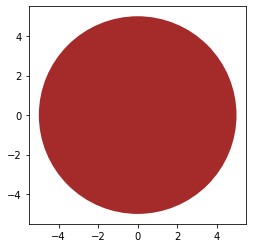

In [349]:
c.drawCircle()

In [350]:

class Rectangle(object):
    
    # Constructor
    def __init__(self, width=2, height=3, color='r'):
        self.height = height 
        self.width = width
        self.color = color
    
    # Method
    def drawRectangle(self):
        plt.gca().add_patch(plt.Rectangle((0, 0), self.width, self.height ,fc=self.color))
        plt.axis('scaled')
        plt.show()

In [351]:
r = Rectangle()

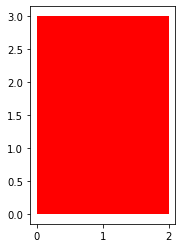

In [352]:
r.drawRectangle()

In [353]:
r1=Rectangle(2,3,color='blue')

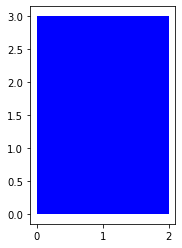

In [356]:
r1.drawRectangle()

## Text Analysis 


You have been recruited by your friend, a linguistics enthusiast, to create a utility tool that can perform analysis on a given piece of text. Complete the class 'analysedText' with the following methods -

Constructor (__init__) - This method should take the argument text, make it lower case, and remove all punctuation. Assume only the following punctuation is used: period (.), exclamation mark (!), comma (,) and question mark (?). Assign this newly formatted text to a new attribute called fmtText.
freqAll - This method should create and return dictionary of all unique words in the text, along with the number of times they occur in the text. Each key in the dictionary should be the unique word appearing in the text and the associated value should be the number of times it occurs in the text. Create this dictionary from the fmtText attribute.
freqOf - This method should take a word as an argument and return the number of occurrences of that word in fmtText.

In [373]:
x = "I AM HRISHI, HK I AM RAAM HRISHI"

In [376]:
y= set(x)
y

{' ', ',', 'A', 'H', 'I', 'K', 'M', 'R', 'S'}

In [369]:
x.lower()

'i am hrishi, hk:'

In [370]:
x.split(',')

['I AM HRISHI', ' HK:']

In [371]:
x.replace(',','')

'I AM HRISHI HK:'

In [372]:
x.replace(':','')

'I AM HRISHI, HK'

In [390]:
class analysedText(object):
    
    def __init__ (self, text):
        # remove punctuation
        formattedText = text.replace('.','').replace('!','').replace('?','').replace(',','')
        
        # make text lowercase
        formattedText = formattedText.lower()
        
        self.fmtText = formattedText
        
    def freqAll(self):        
        # split text into words
        wordList = self.fmtText.split(' ')
        
        # Create dictionary
        freqMap = {}
        for word in set(wordList): # use set to remove duplicates in list
            freqMap[word] = wordList.count(word)
        
        return freqMap
    
    def freqOf(self,word):
        # get frequency map
        freqDict = self.freqAll()
        
        if word in freqDict:
            return freqDict[word]
        else:
            return 0

In [392]:
a = analysedText('I AM HRISHI I AM HRISHI, HK!')

In [394]:
a.fmtText

'i am hrishi i am hrishi hk'

In [397]:
a.freqAll()

{'hk': 1, 'i': 2, 'am': 2, 'hrishi': 2}

In [401]:
a.freqOf('hk')

1